# Introduction

The Telco Customer Churn dataset contains information about a fictional telecommunications company that provided home phone and Internet services to 7,043 customers in California during the third quarter. It indicates which customers left, stayed, or subscribed to their services.
## Dataset 

|Feature|Description|
|---|---|
|`customerID`|Unique identifier of the customers|
|`gender`|Gender|
|`SeniorCitizen`|Is a senior citizen?|
|`Partner`|Has a partner?|
|`Dependents`|Has dependents?|
|`tenure`|Length of relationship (in months)|
|`PhoneService`|Has phone service?|
|`MultipleLines`|Has multiple lines? (Yes, no, no phone service)|
|`InternetService`|Internet service provider (DSL, Fiber, or none)|
|`OnlineSecurity`|Has online security?|
|`OnlineBackup`|Has online backup?|
|`DeviceProtection`|Has device protection?|
|`TechSupport`|Has technical support?|
|`StreamingTV`|Has TV streaming?|
|`StreamingMovies`|Has movie streaming?|
|`Contract`|Contract type (month-to-month, annual, or bi-annual)|
|`PaperlessBilling`|Receives paperless billing?|
|`PaymentMethod`|Payment method|
|`MonthlyCharges`|Service rate|
|`TotalCharges`|Total paid by the customer|
|`Churn`|Target|

# Libraries and data
## Imports 

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# EDA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Notebook config
import warnings
warnings.filterwarnings('ignore')
plt.style.use('fast')
palette = ['#0a369d', '#4472ca', '#5e7ce2', '#92b4f4', '#cfdee7']
sns.set_palette(palette)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)

<Figure size 1000x200 with 0 Axes>

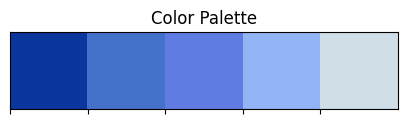

In [2]:
plt.figure(figsize=(10, 2))
sns.palplot(sns.color_palette(palette))
plt.title("Color Palette")
plt.show()

In [5]:


df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")


## Data quality

In [6]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 7043 rows and 21 columns.


In [7]:
print(f"The dataset has: {len(df.select_dtypes(include = 'object').columns.to_list())} categorical columns.")
print(f"The dataset has: {len(df.select_dtypes(include = 'number').columns.to_list())} numerical columns.")

The dataset has: 18 categorical columns.
The dataset has: 3 numerical columns.


In [8]:
df.nunique().sort_values()

Churn                  2
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PaperlessBilling       2
PhoneService           2
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
DeviceProtection       3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Cleaning and manipulation

The necessary changes to proceed with the analysis will be converting the values in the `SeniorCitizen` column to Yes and No, removing the `customerID` column, and adjusting the data type of the `TotalCharges`column. 

In [11]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [12]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [13]:
df = df.drop(columns = ['customerID'], axis = 1)

In [14]:
df.to_csv("../data/processed/clean_data.csv", index = False)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis


In [15]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80


- On average, Telco customers have just over 2 years of relationship with the company (32 months), and the standard deviation indicates high variance
- The average monthly charge is 64.76 USD, reaching up to 118.75 USD

Let’s look for outliers using boxplots.

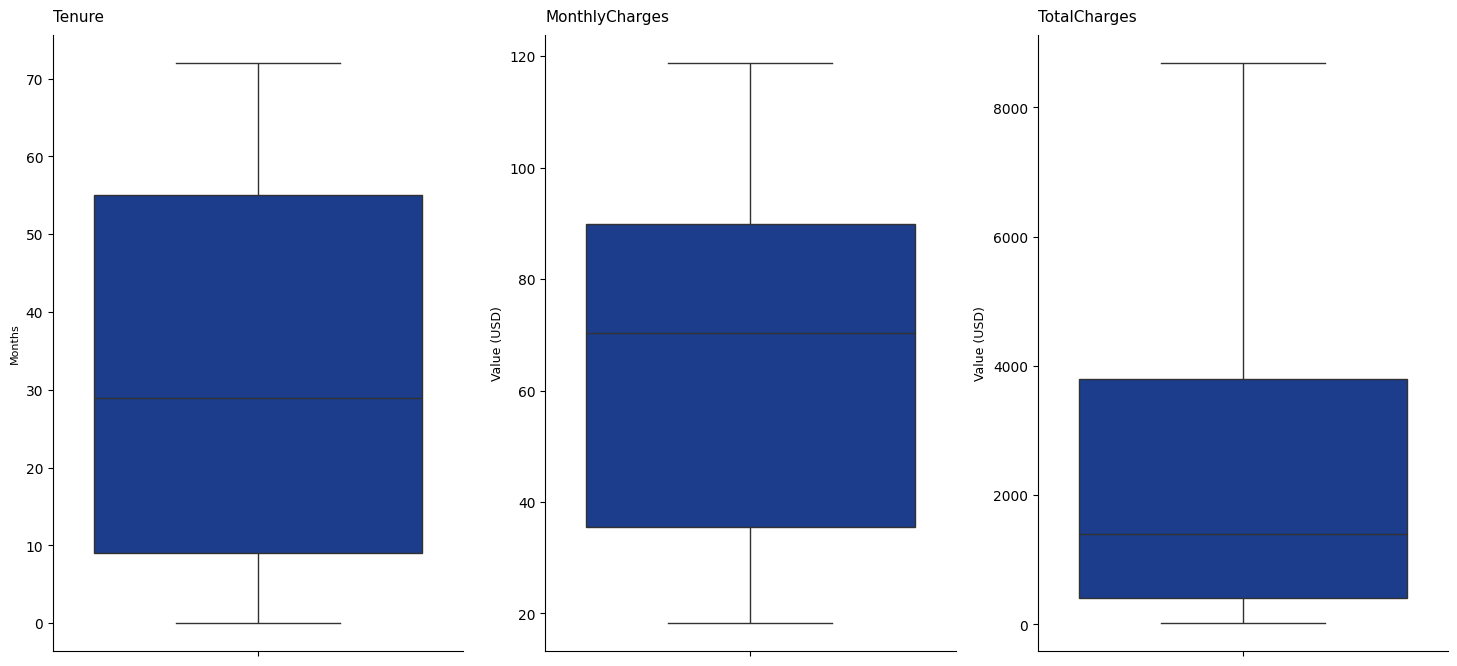

In [16]:
fig, axes = plt.subplots(1, 3, figsize = (18, 8))

sns.boxplot(ax = axes[0], y = df['tenure'])
axes[0].set_title('Tenure', loc = 'left', fontsize = 11, pad = 10)
axes[0].set_ylabel('Months', fontsize = 8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

sns.boxplot(ax = axes[1], y = df['MonthlyCharges'])
axes[1].set_title('MonthlyCharges', loc = 'left', fontsize = 11, pad = 10)
axes[1].set_ylabel('Value (USD)', fontsize = 9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

sns.boxplot(ax = axes[2], y = df['TotalCharges'])
axes[2].set_title('TotalCharges', loc = 'left', fontsize = 11, pad = 10)
axes[2].set_ylabel('Value (USD)', fontsize = 9)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

No outliers were found, so we will proceed to the categorical variables.

In [17]:
df.select_dtypes(exclude = 'number').describe().T

,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [18]:
df['Churn'].value_counts(normalize = True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

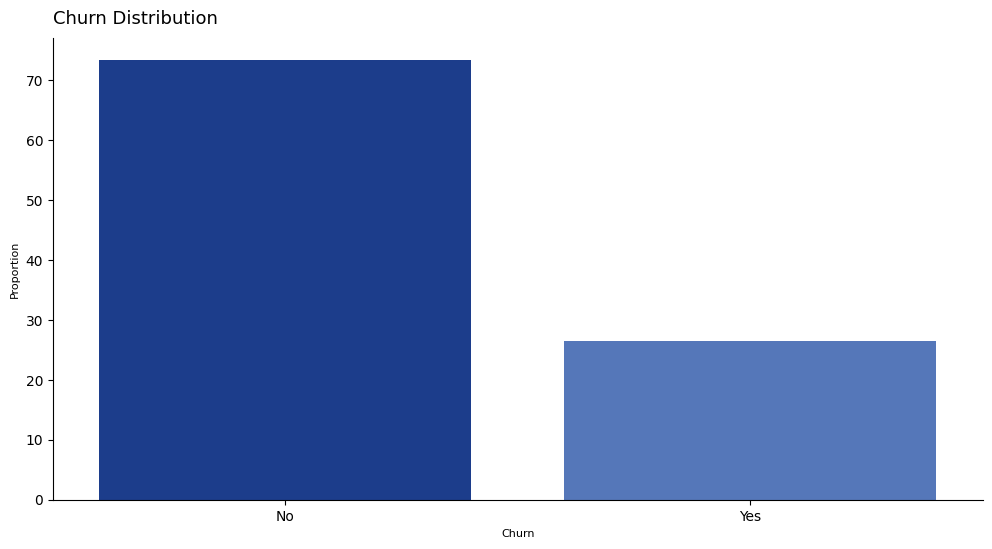

In [19]:
fig, ax = plt.subplots(figsize = (12, 6))

sns.countplot(df, x = 'Churn', hue = 'Churn', stat = 'percent')
ax.set_title('Churn Distribution', fontsize = 13, pad = 10, loc = 'left')
ax.set_xlabel('Churn', fontsize = 8)
ax.set_ylabel('Proportion', fontsize = 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

- The churn rate is 26.53% at Telco Telecom, resulting in a retention rate of 73.46%; the telecommunications industry has an average retention rate of around 69% [*](https://customergauge.com/blog/average-churn-rate-by-industry).
- The most common type of contract is month-to-month.
- The most frequent payment method is paperless billing, with electronic check.

## Bivariate Analysis
### Churn x Internet Service

In [21]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

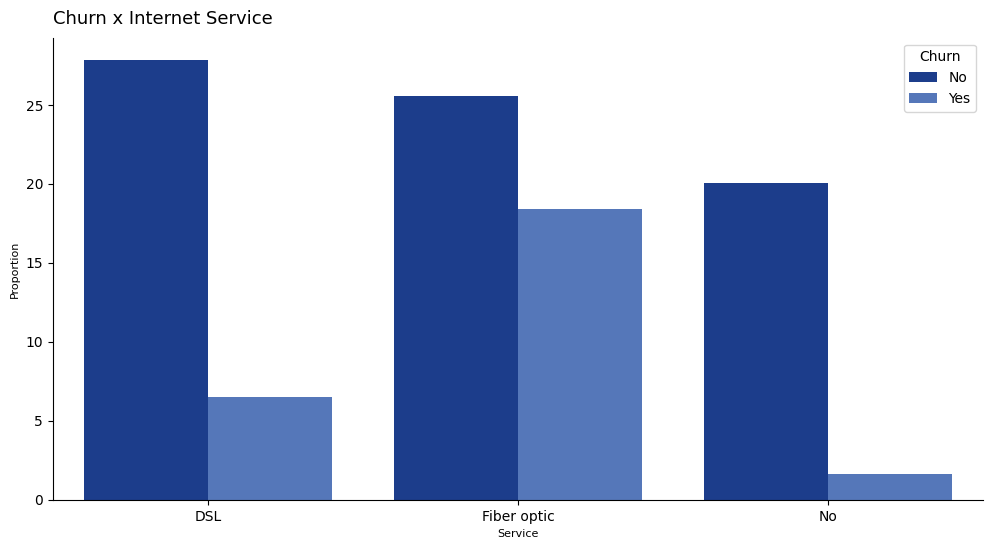

In [22]:
fig, ax = plt.subplots(figsize = (12, 6))

sns.countplot(df, x = 'InternetService', hue = 'Churn', stat = 'percent')
ax.set_title("Churn x Internet Service", fontsize = 13, pad = 10, loc = 'left')
ax.set_xlabel('Service', fontsize = 8)
ax.set_ylabel('Proportion', fontsize = 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

### Churn x Contract Type

In [23]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

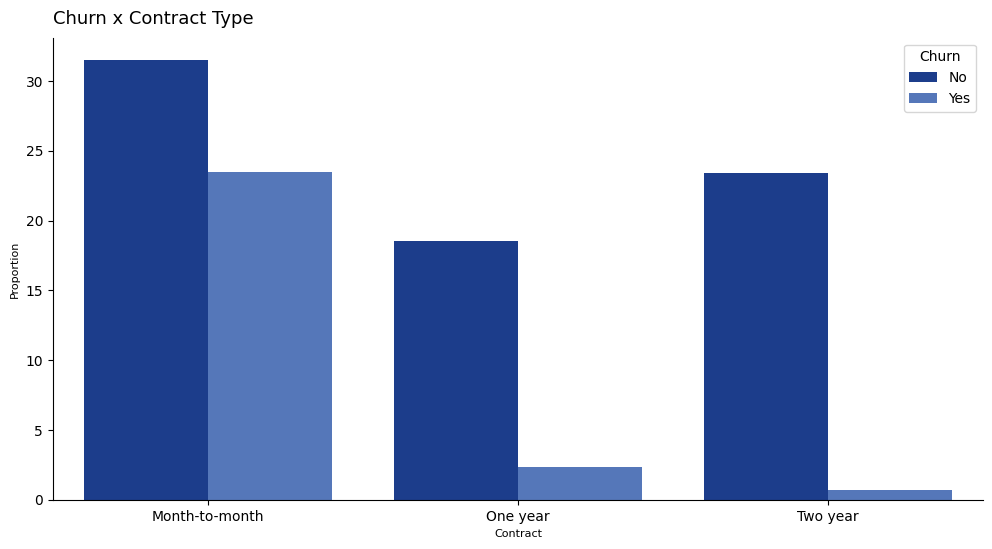

In [24]:
fig, ax = plt.subplots(figsize = (12, 6))

sns.countplot(df, x = 'Contract', hue = 'Churn', stat = 'percent')
ax.set_title("Churn x Contract Type", fontsize = 13, pad = 10, loc = 'left')
ax.set_xlabel('Contract', fontsize = 8)
ax.set_ylabel('Proportion', fontsize = 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

### Churn x Payment Method

In [25]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

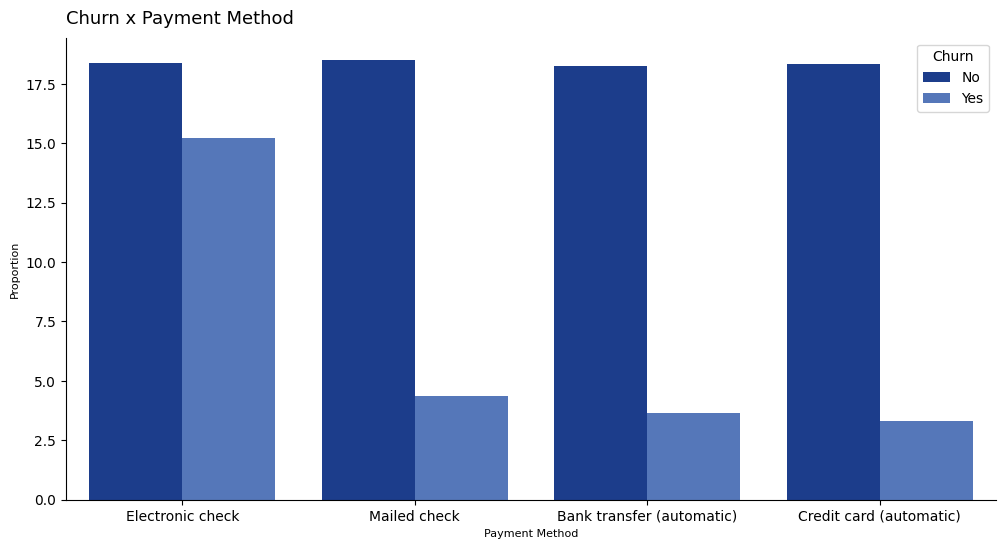

In [26]:
fig, ax = plt.subplots(figsize = (12, 6))

sns.countplot(df, x = 'PaymentMethod', hue = 'Churn', stat = 'percent')
ax.set_title("Churn x Payment Method", fontsize = 13, pad = 10, loc = 'left')
ax.set_xlabel('Payment Method', fontsize = 8)
ax.set_ylabel('Proportion', fontsize = 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

## Testing some hypotheses

### Relationship Time (Tenure)

The longer we remain using a service, often due to attachment or convenience, we tend to avoid canceling it(churn). At the beginning of the contract, being more attentive and less patient with errors is common, let's work on the following hypothesis:

- $H_0:$ The relationship time with the company has no significant effect on the churn probability.
- $H_1:$ People with shorter relationship time with the company have higher churn probability.


In [27]:
group_a = df[df['Churn'] == 'Yes']['tenure']
group_b = df[df['Churn'] == 'No']['tenure']

_, p_value = mannwhitneyu(group_a, group_b, alternative = 'less')

alpha = 0.05

if p_value < alpha:
    print("We reject H0: Clients with shorter relationship time with the company have higher churn probability.")
else:
    print("We do not reject H0: The relationship time with the company has no significant effect on the churn probability.")

We reject H0: Clients with shorter relationship time with the company have higher churn probability.


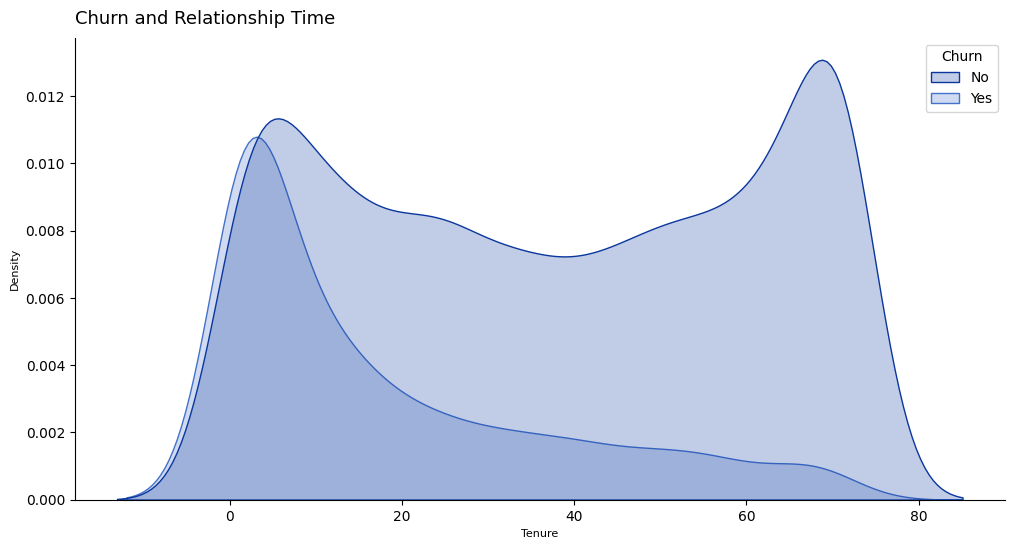

In [ ]:
fig, ax = plt.subplots(figsize = (12, 6))

sns.kdeplot(x = df['tenure'], hue = df['Churn'], fill = True)
ax.set_title("Churn and Relationship Time", fontsize = 13, pad = 10, loc = 'left')
ax.set_xlabel('Tenure', fontsize = 8)
ax.set_ylabel('Density', fontsize = 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

### Monthly Charges

Customers who opt for more expensive services, in most cases, are more attentive and demanding regarding their quality. Let's test the following hypothesis:

- $H_0:$ The monthly charge value has no significant effect on the churn probability.
- $H_1:$ Customers who pay higher monthly charges have higher churn probability.

In [ ]:
group_a = df[df['Churn'] == 'Yes']['MonthlyCharges']
group_b = df[df['Churn'] == 'No']['MonthlyCharges']

_, p_value = mannwhitneyu(group_a, group_b, alternative = 'greater')

alpha = 0.05

if p_value < alpha:
    print("We reject H0: Clients who pay higher monthly charges have higher churn probability.")
else:
    print("We do not reject H0: The monthly charge value has no significant effect on the churn probability.")

We reject H0: Clients who pay higher monthly charges have higher churn probability.


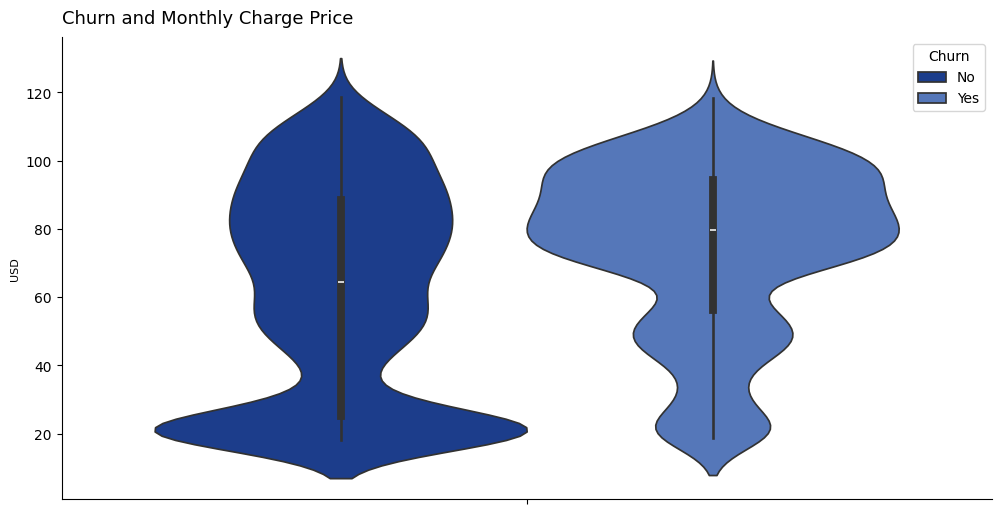

In [ ]:
fig, ax = plt.subplots(figsize = (12, 6))

sns.violinplot(y = df['MonthlyCharges'], hue = df['Churn'])
ax.set_title("Churn and Monthly Charge Price", fontsize = 13, pad = 10, loc = 'left')
ax.set_ylabel('USD', fontsize = 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

## Conclusions

- Customers with shorter relationship time have higher churn probability.
- Those who pay higher monthly charges also have higher churn probability.
- Monthly renewal plans have higher churn probability.
- Automatic payments have lower churn probability.

### Recommendations
- Create customer loyalty actions, such as discounts and special offers.
- Improve service and offer exclusive advantages for customers on more expensive plans.
- Encourage the adoption of annual renewal plans and automatic payments.

It is possible to create an action plan in the form of marketing campaigns and new service plans to reduce the Churn rate at Telco, some options would be (1) offer an annual plan with discount if the chosen payment method is Bank transfer or Credit card, (2) review price and give discounts to customers with longer relationship time who have more expensive plans for annual renewal.